## IMPORT FILES

In [1]:
from pathlib import Path
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tokenizers import Tokenizer

from dataSet import create_dataloader
from gptModel import (
    GPTModel,
    TINYSTORIES_CONFIG_29M,
    count_parameters,
    generate,
    text_to_token_ids,
    token_ids_to_text,
)

from processData import tokenize_split
from train_model import (
    create_optimizer,
    create_warmup_cosine_scheduler,
    evaluate_model,
    train_model,
)

print("PyTorch: ", torch.__version__)

PyTorch:  2.12.0+cu126


## REPRODUCIBILITY, HARDWARE AND RUN MODE

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# CHECK FOR QUICK RUN
QUICK_RUN = False
RESUME_FROM_LATEST = False

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
RUN_NAME = "quick_1m" if QUICK_RUN else "tinystories_25m"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / RUN_NAME

for directory in (DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TOKENIZER_PATH = PROJECT_ROOT / "tinystories_tokenizer.json"

MODEL_CONFIG = dict(TINYSTORIES_CONFIG_29M)
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 16
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
NUM_WORKERS = 0

if QUICK_RUN:
    TRAIN_TOKEN_BUDGET = 1_000_000
    VALIDATION_TOKEN_BUDGET = 250_000
    EVAL_FREQUENCY = 25
    EVAL_BATCHES = 50
    CHECKPOINT_FREQUENCY = 100
else:
    TRAIN_TOKEN_BUDGET = 25_000_000
    VALIDATION_TOKEN_BUDGET = 1_000_000
    EVAL_FREQUENCY = 100
    EVAL_BATCHES = 100
    CHECKPOINT_FREQUENCY = 1_000

TRAIN_TOKEN_FILE = DATA_DIR / f"tinystories_train_{TRAIN_TOKEN_BUDGET}.bin"
VALIDATION_TOKEN_FILE = DATA_DIR / f"tinystories_validation_{VALIDATION_TOKEN_BUDGET}.bin"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
    )
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
else:
    print("WARNING: CUDA is unavailable. Use CPU only for a tiny smoke test.")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 6.00 GB


## LOAD AND VERIFY THE TOKENIZER

In [3]:
tokenizer = Tokenizer.from_file(str(TOKENIZER_PATH))
vocab_size = tokenizer.get_vocab_size()
eos_id = tokenizer.token_to_id("<|endoftext|>")
unk_id = tokenizer.token_to_id("<|unk|>")

assert vocab_size == MODEL_CONFIG["vocab_size"], (
    f"Tokenizer has {vocab_size} tokens, but model config expects "
    f"{MODEL_CONFIG['vocab_size']}."
)
assert eos_id is not None
assert unk_id is not None
assert vocab_size == MODEL_CONFIG["vocab_size"]

sample_text = "Once upon a time, a little dragon found a red ball."
encoding = tokenizer.encode(sample_text)

assert max(encoding.ids) < vocab_size
assert min(encoding.ids) >= 0
assert tokenizer.decode(encoding.ids) == sample_text

print("Vocabulary size:", vocab_size)
print("UNK ID:", unk_id, "EOS ID:", eos_id)
print("Token IDs:", encoding.ids)
print("Tokens:", encoding.tokens)
print("Decoded:", tokenizer.decode(encoding.ids))

test_texts = [
    "Hello!",
    "Tom said, \"Let's go!\"",
    "The cat\nran outside.",
    "Lily had 3 red apples.",
    "Once upon a time, there was a tiny blue bird.",
]

for text in test_texts:
    encoded = tokenizer.encode(text)

    print("=" * 60)
    print("Original:", repr(text))
    print("IDs:", encoded.ids)
    print("Tokens:", encoded.tokens)
    print("Decoded:", repr(tokenizer.decode(encoded.ids)))
    print("Contains UNK:", unk_id in encoded.ids)

    assert all(0 <= token_id < vocab_size for token_id in encoded.ids)
    assert tokenizer.decode(encoded.ids) == text

Vocabulary size: 8000
UNK ID: 0 EOS ID: 1
Token IDs: [433, 448, 260, 397, 13, 260, 399, 1768, 598, 260, 928, 671, 15]
Tokens: ['Once', 'Ġupon', 'Ġa', 'Ġtime', ',', 'Ġa', 'Ġlittle', 'Ġdragon', 'Ġfound', 'Ġa', 'Ġred', 'Ġball', '.']
Decoded: Once upon a time, a little dragon found a red ball.
Original: 'Hello!'
IDs: [1415, 2]
Tokens: ['Hello', '!']
Decoded: 'Hello!'
Contains UNK: False
Original: 'Tom said, "Let\'s go!"'
IDs: [739, 329, 13, 333, 953, 372, 438, 426]
Tokens: ['Tom', 'Ġsaid', ',', 'Ġ"', 'Let', "'s", 'Ġgo', '!"']
Decoded: 'Tom said, "Let\'s go!"'
Contains UNK: False
Original: 'The cat\nran outside.'
IDs: [375, 697, 200, 83, 301, 682, 15]
Tokens: ['The', 'Ġcat', 'Ċ', 'r', 'an', 'Ġoutside', '.']
Decoded: 'The cat\nran outside.'
Contains UNK: False
Original: 'Lily had 3 red apples.'
IDs: [343, 362, 2023, 928, 2188, 15]
Tokens: ['Lily', 'Ġhad', 'Ġ3', 'Ġred', 'Ġapples', '.']
Decoded: 'Lily had 3 red apples.'
Contains UNK: False
Original: 'Once upon a time, there was a tiny blue bir

## PREPARE BINARY TOKEN FILES:
The preprcessing function streams TinyStories, inserts EOS between stories, and stores IDs as uint16. Writes to a temporary file first, so an interrupted run does not look like a valid complete dataset.

In [4]:
def ensure_token_file(path, expected_tokens, split, shuffle_buffer_size):
    existing_tokens = (
        path.stat().st_size // np.dtype(np.uint16).itemsize
        if path.exists()
        else 0
    )

    if existing_tokens == expected_tokens:
        print(f"Ready: {path} ({existing_tokens:,} tokens)")
        return

    if path.exists():
        print(
            f"Rebuilding {path}: found {existing_tokens:,} tokens, "
            f"expected {expected_tokens:,}."
        )

    tokenize_split(
        split=split,
        output_file=path,
        tokenizer_file=TOKENIZER_PATH,
        max_tokens=expected_tokens,
        shuffle_buffer_size=shuffle_buffer_size,
        seed=SEED,
        overwrite=True,
    )


ensure_token_file(
    TRAIN_TOKEN_FILE,
    TRAIN_TOKEN_BUDGET,
    split="train",
    shuffle_buffer_size=10_000,
)
ensure_token_file(
    VALIDATION_TOKEN_FILE,
    VALIDATION_TOKEN_BUDGET,
    split="validation",
    shuffle_buffer_size=0,
)

Ready: C:\Users\owner\Desktop\Transformer\data\tinystories_train_25000000.bin (25,000,000 tokens)


Tokenizing validation:   0%|          | 0.00/1.00M [00:00<?, ?tok/s]

Wrote 1,000,000 tokens to C:\Users\owner\Desktop\Transformer\data\tinystories_validation_1000000.bin


CREATE DATA LOADERS AND CALCULATE THE TRAINING BUDGET

In [5]:
train_loader = create_dataloader(
    token_file=TRAIN_TOKEN_FILE,
    context_length=MODEL_CONFIG["context_length"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
    drop_last=True,
    seed=SEED,
)

validation_loader = create_dataloader(
    token_file=VALIDATION_TOKEN_FILE,
    context_length=MODEL_CONFIG["context_length"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
    drop_last=False,
    seed=SEED,
)

effective_tokens_per_update = (
    BATCH_SIZE
    * MODEL_CONFIG["context_length"]
    * GRADIENT_ACCUMULATION_STEPS
)

# One pass over the selected training token file.
MAX_OPTIMIZER_STEPS = max(
    1,
    len(train_loader) // GRADIENT_ACCUMULATION_STEPS,
)
WARMUP_STEPS = max(10, int(0.03 * MAX_OPTIMIZER_STEPS))

print("Training sequences:", len(train_loader.dataset))
print("Validation sequences:", len(validation_loader.dataset))
print("Training micro-batches:", len(train_loader))
print("Effective tokens/update:", f"{effective_tokens_per_update:,}")
print("Optimizer steps:", f"{MAX_OPTIMIZER_STEPS:,}")
print("Warmup steps:", WARMUP_STEPS)
print(
    "Approximate optimized tokens:",
    f"{MAX_OPTIMIZER_STEPS * effective_tokens_per_update:,}",
)

Training sequences: 97656
Validation sequences: 3906
Training micro-batches: 48828
Effective tokens/update: 8,192
Optimizer steps: 3,051
Warmup steps: 91
Approximate optimized tokens: 24,993,792


## INSPECTION AND VISUALIZATION OF DATA

In [6]:
input_batch, target_batch = next(iter(train_loader))

print("Input shape:", tuple(input_batch.shape))
print("Target shape:", tuple(target_batch.shape))
print("Dtype:", input_batch.dtype)
print("Minimum/maximum token ID:", input_batch.min().item(), input_batch.max().item())
print("Shift is correct:", torch.equal(input_batch[0, 1:], target_batch[0, :-1]))

print("\nDecoded input window:\n")
print(tokenizer.decode(input_batch[0].tolist(), skip_special_tokens=False))

print("\nFirst 30 input IDs:\n", input_batch[0, :30].tolist())
print("First 30 target IDs:\n", target_batch[0, :30].tolist())

Input shape: (2, 256)
Target shape: (2, 256)
Dtype: torch.int64
Minimum/maximum token ID: 1 7478
Shift is correct: True

Decoded input window:

 and her friends always remembered that special day. They all still love going to the shore, and nothing ever melted their hearts like that special candy.<|endoftext|>Sara loved blueberries. She liked to eat them for breakfast, snack and dessert. She liked to make blueberry pies, muffins and jam with her mom. She liked to pick blueberries from the bushes in the garden. She liked to share blueberries with her friends and family.

One day, Sara's mom told her they were going to visit her grandma. Sara was happy, because she loved her grandma. She wanted to bring her a gift. She decided to make a blueberry pie for her grandma, because she knew her grandma loved blueberries too.

Sara and her mom baked the pie together. They mixed the flour, the butter, the sugar and the eggs. They rolled the dough and put it in the pan. They filled it with blueber

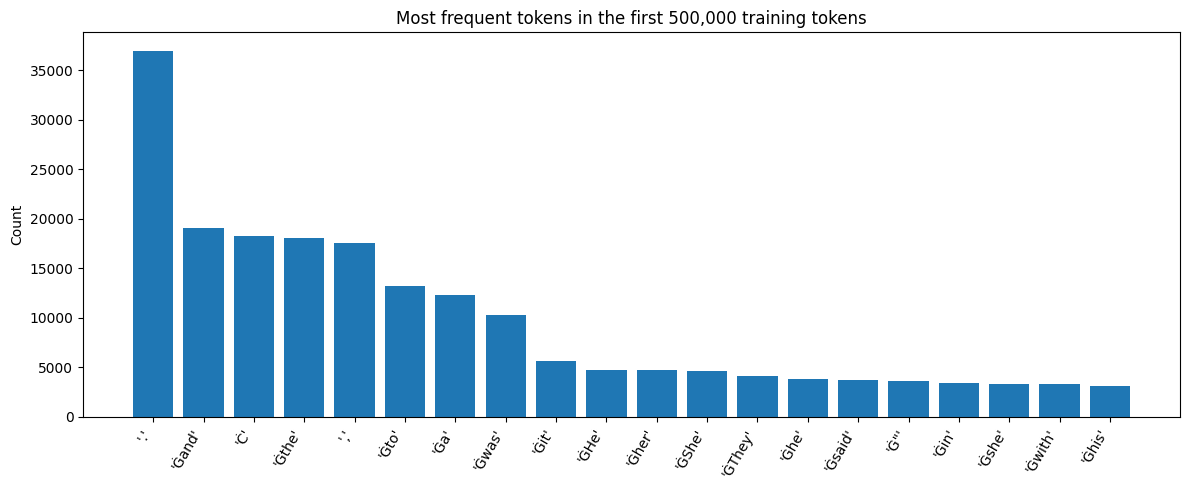

In [7]:
# Plot the most frequent tokens in a sample of the binary training stream.
train_tokens = np.memmap(TRAIN_TOKEN_FILE, dtype=np.uint16, mode="r")
sample_count = min(500_000, len(train_tokens))
sampled_ids = np.asarray(train_tokens[:sample_count], dtype=np.int64)
frequencies = np.bincount(sampled_ids, minlength=vocab_size)
top_ids = np.argsort(frequencies)[-20:][::-1]
labels = [repr(tokenizer.id_to_token(int(token_id))) for token_id in top_ids]

plt.figure(figsize=(12, 5))
plt.bar(labels, frequencies[top_ids])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Count")
plt.title(f"Most frequent tokens in the first {sample_count:,} training tokens")
plt.tight_layout()
plt.show()

## BUILD THE MODEL AND VERIFY ITS ARCHITECTURE

In [8]:
model = GPTModel(MODEL_CONFIG).to(device)
parameter_count = count_parameters(model)

print(model)
print(f"\nParameters: {parameter_count:,} ({parameter_count / 1e6:.2f}M)")
print(
    "Embedding weights tied:",
    model.tok_emb.weight.data_ptr() == model.out_head.weight.data_ptr(),
)

assert parameter_count == 29_434_880
assert model.tok_emb.weight.data_ptr() == model.out_head.weight.data_ptr()

GPTModel(
  (tok_emb): Embedding(8000, 512)
  (pos_emb): Embedding(256, 512)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=512, out_features=512, bias=False)
        (W_key): Linear(in_features=512, out_features=512, bias=False)
        (W_value): Linear(in_features=512, out_features=512, bias=False)
        (out_proj): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='tanh')
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
      )
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
      (drop_shortcut): Dropout(p=

## MANDATORY SMOKE TEST BEFORE THE LONG RUN
This performs a real forward and backward pass using the intended batch size. It catches shape errors, invalid token IDs, and most VRAM problems before the multi-hour run. The model is recreated afterward so the actual run starts from clean initialization

In [9]:
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

model.train()
smoke_inputs = input_batch.to(device, non_blocking=True)
smoke_targets = target_batch.to(device, non_blocking=True)

if device.type == "cuda":
    autocast_context = torch.amp.autocast("cuda", dtype=torch.float16)
else:
    from contextlib import nullcontext
    autocast_context = nullcontext()

with autocast_context:
    smoke_logits = model(smoke_inputs)
    smoke_loss = F.cross_entropy(
        smoke_logits.flatten(0, 1),
        smoke_targets.flatten(),
    )

smoke_loss.backward()
print("Logit shape:", tuple(smoke_logits.shape))
print("Smoke-test loss:", smoke_loss.item())
print("Finite loss:", math.isfinite(smoke_loss.item()))

if device.type == "cuda":
    print(
        "Peak allocated VRAM:",
        f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GB",
    )

assert smoke_logits.shape == (
    BATCH_SIZE,
    MODEL_CONFIG["context_length"],
    MODEL_CONFIG["vocab_size"],
)
assert math.isfinite(smoke_loss.item())

del model, smoke_logits, smoke_loss
if device.type == "cuda":
    torch.cuda.empty_cache()

Logit shape: (2, 256, 8000)
Smoke-test loss: 9.023612976074219
Finite loss: True
Peak allocated VRAM: 0.30 GB


## RECREATE A CLEARN MODEL, OPTIMIZER, AND LEARNING-RATE SCHEDULER

In [10]:
# Re-seed so the clean model initialization is reproducible.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = GPTModel(MODEL_CONFIG).to(device)
optimizer = create_optimizer(
    model,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),
)
scheduler = create_warmup_cosine_scheduler(
    optimizer,
    warmup_steps=WARMUP_STEPS,
    total_steps=MAX_OPTIMIZER_STEPS,
    min_lr_ratio=0.1,
)

resume_path = CHECKPOINT_DIR / "latest.pt" if RESUME_FROM_LATEST else None
if resume_path is not None and not resume_path.exists():
    raise FileNotFoundError(resume_path)

print("Initial learning rate:", optimizer.param_groups[0]["lr"])
print("Resume checkpoint:", resume_path)

Initial learning rate: 3.2967032967032968e-06
Resume checkpoint: None


## OPTIONAL BASELINE GENERATION BEFORE TRAINING

In [11]:
prompt = "Once upon a time, there was a little dragon"
prompt_ids = text_to_token_ids(prompt, tokenizer).to(device)

baseline_ids = generate(
    model=model,
    idx=prompt_ids,
    max_new_tokens=80,
    context_size=MODEL_CONFIG["context_length"],
    temperature=0.8,
    top_k=40,
    eos_id=eos_id,
)

baseline_text = token_ids_to_text(
    baseline_ids,
    tokenizer,
    skip_special_tokens=True,
)
print(baseline_text)

Once upon a time, there was a little dragon screwdriver slimy fair screwdriver driveway sweets comfortable peacefulasm frustr objects wonders collecting Davey computer flown built Davey Tw spike folder Granny cute sandwiches squeaked Frank supply serve Tw widavy backed stage wasting folder flown slippery earlyMiss Tim potato roaring giggles bushes feeling job bicy costumasm thiefYeœYouâ Frank snail fair shadeMiss offer bright travelledord flat herRoseebookitingffee Bee opened see looks eraser refle�- bushes musician her screwdriver slippery


## TRAIN THE MODEL

For the first execution, keep `QUICK_RUN = True`. Only start the 25M-token run after the quick run finishes, creates checkpoints, produces finite losses, and generates a plot.

In [12]:
training_start = time.perf_counter()

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=validation_loader,
    optimizer=optimizer,
    device=device,
    max_optimizer_steps=MAX_OPTIMIZER_STEPS,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    eval_frequency=EVAL_FREQUENCY,
    checkpoint_frequency=CHECKPOINT_FREQUENCY,
    eval_batches=EVAL_BATCHES,
    scheduler=scheduler,
    checkpoint_dir=CHECKPOINT_DIR,
    resume_from=resume_path,
    keep_step_checkpoints=False,
)

training_hours = (time.perf_counter() - training_start) / 3600
print(f"Training call completed in {training_hours:.2f} hours")

Training:   0%|          | 0/3051 [00:00<?, ?step/s]

Step 100 | tokens 819,200 | train 6.2955 | val 4.3562 | lr 3.00e-04
Step 200 | tokens 1,638,400 | train 4.2103 | val 3.7244 | lr 2.99e-04
Step 300 | tokens 2,457,600 | train 3.8231 | val 3.4165 | lr 2.97e-04
Step 400 | tokens 3,276,800 | train 3.5816 | val 3.1837 | lr 2.93e-04
Step 500 | tokens 4,096,000 | train 3.3922 | val 3.0124 | lr 2.87e-04
Step 600 | tokens 4,915,200 | train 3.2353 | val 2.8582 | lr 2.81e-04
Step 700 | tokens 5,734,400 | train 3.1275 | val 2.7548 | lr 2.73e-04
Step 800 | tokens 6,553,600 | train 3.0231 | val 2.6566 | lr 2.64e-04
Step 900 | tokens 7,372,800 | train 2.9392 | val 2.5796 | lr 2.53e-04
Step 1,000 | tokens 8,192,000 | train 2.8675 | val 2.5120 | lr 2.42e-04
Step 1,100 | tokens 9,011,200 | train 2.8179 | val 2.4535 | lr 2.30e-04
Step 1,200 | tokens 9,830,400 | train 2.7641 | val 2.4018 | lr 2.17e-04
Step 1,300 | tokens 10,649,600 | train 2.7074 | val 2.3499 | lr 2.03e-04
Step 1,400 | tokens 11,468,800 | train 2.6718 | val 2.3082 | lr 1.89e-04
Step 1,500

## SAVE AND PLOT THE METRICS

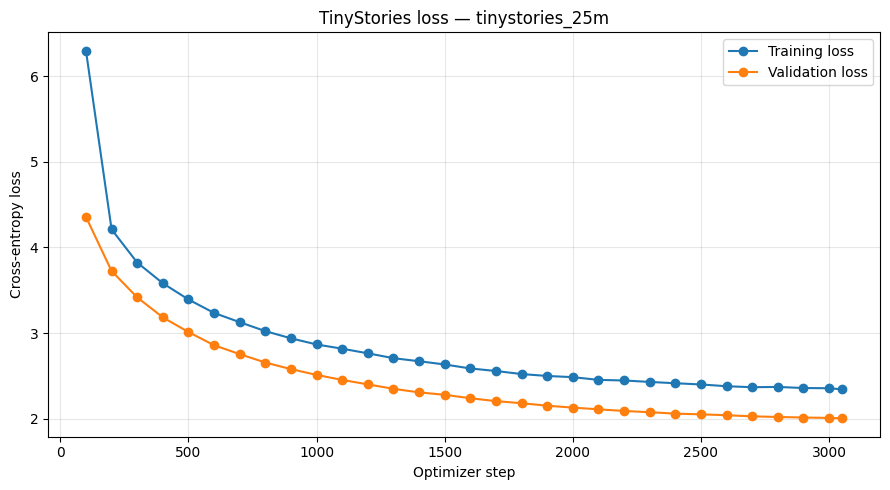

History: C:\Users\owner\Desktop\Transformer\outputs\tinystories_25m_training_history.json
Plot: C:\Users\owner\Desktop\Transformer\outputs\tinystories_25m_loss_curve.png
Best validation loss: 2.005335075855255


In [13]:
history_path = OUTPUT_DIR / f"{RUN_NAME}_training_history.json"
with history_path.open("w", encoding="utf-8") as file:
    json.dump(history, file, indent=2)

steps = history["optimizer_step"]

plt.figure(figsize=(9, 5))
plt.plot(steps, history["train_loss"], marker="o", label="Training loss")
plt.plot(steps, history["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Optimizer step")
plt.ylabel("Cross-entropy loss")
plt.title(f"TinyStories loss — {RUN_NAME}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_plot_path = OUTPUT_DIR / f"{RUN_NAME}_loss_curve.png"
plt.savefig(loss_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("History:", history_path)
print("Plot:", loss_plot_path)
print("Best validation loss:", min(history["val_loss"]))

## LOAD THE BEST CHECKPOINT AND GENERATE FINAL SAMPLES

In [14]:
best_checkpoint_path = CHECKPOINT_DIR / "best.pt"
best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=False,
)
model.load_state_dict(best_checkpoint["model"])
model.eval()

prompts = [
    "Once upon a time, there was a little dragon",
    "Lily was afraid of the dark, but one night",
    "Tom found a strange box under his bed",
]

generated_samples = {}
for prompt in prompts:
    prompt_ids = text_to_token_ids(prompt, tokenizer).to(device)
    output_ids = generate(
        model=model,
        idx=prompt_ids,
        max_new_tokens=180,
        context_size=MODEL_CONFIG["context_length"],
        temperature=0.8,
        top_k=40,
        eos_id=eos_id,
    )
    generated_text = token_ids_to_text(
        output_ids,
        tokenizer,
        skip_special_tokens=True,
    )
    generated_samples[prompt] = generated_text
    print("=" * 90)
    print(generated_text)

samples_path = OUTPUT_DIR / f"{RUN_NAME}_generated_samples.json"
with samples_path.open("w", encoding="utf-8") as file:
    json.dump(generated_samples, file, indent=2, ensure_ascii=False)

print("\nSaved samples to:", samples_path)

Once upon a time, there was a little dragon with bright eyes. In the forest, there was an unknown bird. He wanted to be friends with the big bird. He asked his friend, the fox, "Can I join you?". The fox smiled and said, "Yes, but you can keep me safe." The fox decided to be kind and they took turns and started playing together.

As the mouse was walking, the fox saw something beautiful. It was a small, furry rabbit! The rabbit said, "Thank you for helping me find my way home!" The fox was happy and said, "You're welcome, little rabbit!"
Lily was afraid of the dark, but one night, she heard a noise coming from the room. It had a big black cat running towards her and Max. He was scared and ran away.

Lily and Max ran as fast as they could, and they ran away from the dark door. They never saw the light again.
Tom found a strange box under his bed. He opened the box and found a shiny key. It was shiny and shiny.

Tom was so happy. He had found something and he took it home. He showed it t

## SAVE A COMPACT MODEL ONLY ARTIFACT

In [15]:
model_artifact_path = OUTPUT_DIR / f"{RUN_NAME}_best_model.pt"
torch.save(
    {
        "model": model.state_dict(),
        "config": MODEL_CONFIG,
        "tokenizer_file": TOKENIZER_PATH.name,
        "optimizer_step": best_checkpoint["optimizer_step"],
        "tokens_seen": best_checkpoint["tokens_seen"],
        "best_val_loss": best_checkpoint["best_val_loss"],
    },
    model_artifact_path,
)

print("Model artifact:", model_artifact_path)
print(
    "Artifact size:",
    f"{model_artifact_path.stat().st_size / 1024**2:.1f} MB",
)

Model artifact: C:\Users\owner\Desktop\Transformer\outputs\tinystories_25m_best_model.pt
Artifact size: 112.3 MB
